# Preprocessing danych – Transfer Learning w predykcji bioaktywności

**Autor:** Jędrzej  
**Temat 10:** Transfer learning w predykcji bioaktywności dla słabo opisanych celów biologicznych

---

### Strategia danych

| Zbiór                | Źródło                      | Zawartość                                |
| -------------------- | --------------------------- | ---------------------------------------- |
| **upstream**         | ChEMBL API (wiele targetów) | dane treningowe do pre-trenowania modelu |
| **downstream BACE1** | ChEMBL API                  | cel docelowy 1                           |
| **downstream TYK2**  | ChEMBL API                  | cel docelowy 2                           |
| **downstream A2a**   | ChEMBL API                  | cel docelowy 3                           |


## 0. Instalacja zależności


In [17]:
import subprocess, sys
packages = [
    "chembl_webresource_client", "rdkit", "pandas", "numpy",
    "matplotlib", "seaborn", "scikit-learn", "tqdm", "umap-learn",
]
for pkg in packages:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])
print("✅ Paczki zainstalowane")

✅ Paczki zainstalowane


## 1. Import bibliotek


In [18]:
import os, warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import AllChem
RDLogger.DisableLog("rdApp.*")

from sklearn.decomposition import PCA

os.makedirs("./data", exist_ok=True)
os.makedirs("./data/downstream", exist_ok=True)
os.makedirs("./data/upstream", exist_ok=True)
print("✅ Biblioteki załadowane")

✅ Biblioteki załadowane


## 2. Pobranie danych UPSTREAM z ChEMBL API

Upstream = wiele różnych celów biologicznych (kinazy, receptory, proteazy...),  
**z wykluczeniem** BACE1, TYK2 i A2a (żeby nie było wycieku danych do downstream).

Używamy farmakologicznie istotnych targetów z ChEMBL — te same które były w oryginalnym datasecie `multitarget-bioactivity-chembl`.


In [19]:
from chembl_webresource_client.new_client import new_client

activity_client = new_client.activity

# ── Cele downstream – WYKLUCZONE z upstreamu ────────────────────────────────
DOWNSTREAM_TARGETS = {
    "BACE1": "CHEMBL4822",
    "TYK2":  "CHEMBL3553",
    "A2a":   "CHEMBL251",
}

# ── Cele upstream – farmakologicznie istotne, różnorodne ────────────────────
# Wybrane tak żeby pokrywały różne klasy białek (kinazy, GPCRy, proteazy, etc.)
# i żeby dawały dobry transfer do BACE1/TYK2/A2a
UPSTREAM_TARGETS = {
    # Kinazy (podobne do TYK2)
    "JAK1":     "CHEMBL2835",
    "JAK2":     "CHEMBL2971",
    "JAK3":     "CHEMBL5250",
    "EGFR":     "CHEMBL203",
    "CDK2":     "CHEMBL301",
    "p38alpha":  "CHEMBL260",
    # Proteazy aspartylowe (podobne do BACE1)
    "BACE2":    "CHEMBL3717",
    "Cathepsin_D": "CHEMBL1865",
    "Renin":    "CHEMBL286",
    "Pepsin":   "CHEMBL3880",
    # Receptory adenozynowe i GPCRy (podobne do A2a)
    "A1":       "CHEMBL226",
    "A2b":      "CHEMBL254",
    "A3":       "CHEMBL252",
    "DRD2":     "CHEMBL217",   # receptor dopaminowy D2
    "5HT2A":    "CHEMBL224",   # receptor serotoninowy
    # Inne
    "HDAC1":    "CHEMBL325",
    "PARP1":    "CHEMBL3105",
    "HSP90":    "CHEMBL3880757",
}


print(f"Cele upstream:     {len(UPSTREAM_TARGETS)}")
print(f"Cele downstream:   {len(DOWNSTREAM_TARGETS)}")
print(f"\nUpstream targets:")
for name, cid in UPSTREAM_TARGETS.items():
    print(f"  {name:<20} {cid}")

Cele upstream:     18
Cele downstream:   3

Upstream targets:
  JAK1                 CHEMBL2835
  JAK2                 CHEMBL2971
  JAK3                 CHEMBL5250
  EGFR                 CHEMBL203
  CDK2                 CHEMBL301
  p38alpha             CHEMBL260
  BACE2                CHEMBL3717
  Cathepsin_D          CHEMBL1865
  Renin                CHEMBL286
  Pepsin               CHEMBL3880
  A1                   CHEMBL226
  A2b                  CHEMBL254
  A3                   CHEMBL252
  DRD2                 CHEMBL217
  5HT2A                CHEMBL224
  HDAC1                CHEMBL325
  PARP1                CHEMBL3105
  HSP90                CHEMBL3880757


In [20]:
def fetch_bioactivity(target_chembl_id: str,
                       standard_types=None,
                       max_records: int = None) -> pd.DataFrame:
    """
    Pobiera aktywności biologiczne z ChEMBL dla danego celu.
    
    Parametry
    ---------
    target_chembl_id : str  – ID celu
    standard_types   : list – typy miar (domyślnie IC50, Ki, Kd, EC50)
    max_records      : int  – limit rekordów na typ miary (None = wszystkie)
    """
    if standard_types is None:
        standard_types = ["IC50", "Ki", "Kd", "EC50"]

    records = []
    for stype in standard_types:
        res = activity_client.filter(
            target_chembl_id=target_chembl_id,
            standard_type=stype,
            standard_relation="=",
        ).only(
            "molecule_chembl_id", "canonical_smiles",
            "standard_value", "standard_units",
            "standard_type", "pchembl_value",
            "assay_chembl_id",
        )
        batch = list(res)
        if max_records:
            batch = batch[:max_records]
        records.extend(batch)

    return pd.DataFrame.from_records(records)


# ── Pobierz upstream ─────────────────────────────────────────────────────────
# max_records=2000 per target żeby nie czekać zbyt długo
# usuń max_records jeśli chcesz wszystkie dane (może potrwać ~30 min)

upstream_parts = []
failed = []

for name, chembl_id in tqdm(UPSTREAM_TARGETS.items(), desc="Pobieranie upstream"):
    try:
        df = fetch_bioactivity(chembl_id)
        df["target_name"]      = name
        df["target_chembl_id"] = chembl_id
        upstream_parts.append(df)
        print(f"  ✅ {name:<20} → {len(df):>5} rekordów")
    except Exception as e:
        print(f"  ❌ {name:<20} → błąd: {e}")
        failed.append(name)

df_upstream_raw = pd.concat(upstream_parts, ignore_index=True)
df_upstream_raw.to_csv("./data/upstream/upstream_raw.csv", index=False)

print(f"\n📊 Upstream łącznie: {len(df_upstream_raw)} rekordów")
print(f"   Targetów z błędem: {failed if failed else 'brak'}")
print("\nKolumny:", df_upstream_raw.columns.tolist())
df_upstream_raw.head(3)

Pobieranie upstream:   6%|▌         | 1/18 [00:00<00:14,  1.14it/s]

  ✅ JAK1                 → 15001 rekordów


Pobieranie upstream:  11%|█         | 2/18 [00:02<00:16,  1.06s/it]

  ✅ JAK2                 → 18938 rekordów
  ✅ JAK3                 →    25 rekordów


Pobieranie upstream:  22%|██▏       | 4/18 [00:03<00:11,  1.26it/s]

...

  ✅ HDAC1                → 10261 rekordów


Pobieranie upstream: 100%|██████████| 18/18 [00:08<00:00,  2.12it/s]

  ✅ PARP1                →  5896 rekordów
  ✅ HSP90                →     0 rekordów



📊 Upstream łącznie: 137851 rekordów
   Targetów z błędem: brak

Kolumny: ['assay_chembl_id', 'canonical_smiles', 'molecule_chembl_id', 'pchembl_value', 'standard_type', 'standard_units', 'standard_value', 'type', 'units', 'value', 'target_name', 'target_chembl_id']


,assay_chembl_id,canonical_smiles,molecule_chembl_id,pchembl_value,standard_type,standard_units,standard_value,type,units,value,target_name,target_chembl_id
0,CHEMBL857179,CC(C)N(CCC(=O)c1ccc2ccccc2c1)Cc1ccccc1.Cl,CHEMBL538798,4.40,IC50,nM,39810.72,Log IC50,NaN,-4.4,JAK1,CHEMBL2835
1,CHEMBL857179,C=CC(=O)c1ccc2ccccc2c1,CHEMBL154580,4.70,IC50,nM,19952.62,Log IC50,NaN,-4.7,JAK1,CHEMBL2835
2,CHEMBL910181,CN(C)[C@H]1CCCN(c2ccc(C(F)(F)F)cc2NC(=O)c2cc(C...,CHEMBL386637,5.89,IC50,nM,1300.0,IC50,nM,1300.0,JAK1,CHEMBL2835


## 3. Pobranie danych DOWNSTREAM z ChEMBL (BACE1, TYK2, A2a)


In [21]:
downstream_dfs = {}
for name, chembl_id in DOWNSTREAM_TARGETS.items():
    print(f"Pobieranie {name} ({chembl_id}) ...", end=" ")
    df = fetch_bioactivity(chembl_id)   # bez limitu – downstream mały
    df["target_name"]      = name
    df["target_chembl_id"] = chembl_id
    downstream_dfs[name]   = df
    df.to_csv(f"./data/downstream/{name}_raw.csv", index=False)
    print(f"→ {len(df)} rekordów")

print("\n✅ Downstream pobrane")

Pobieranie BACE1 (CHEMBL4822) ... → 15769 rekordów
Pobieranie TYK2 (CHEMBL3553) ... → 10945 rekordów
Pobieranie A2a (CHEMBL251) ... → 8751 rekordów

✅ Downstream pobrane


## 4. Czyszczenie danych


In [ ]:
def is_valid_smiles(smi) -> bool:
    try:
        return Chem.MolFromSmiles(str(smi)) is not None
    except:
        return False


def clean_bioactivity_df(df: pd.DataFrame,
                          smiles_col="canonical_smiles",
                          value_col="standard_value") -> pd.DataFrame:
    """
    Czyści DataFrame z danymi bioaktywności:
    1. Usuwa wiersze bez SMILES / wartości aktywności
    2. Konwertuje wartości na float
    3. Waliduje SMILES przez RDKit
    4. Usuwa duplikaty
    """
    n0 = len(df)
    df = df.copy()

    # 1. Usuń NaN
    df = df.dropna(subset=[smiles_col, value_col])
    print(f"  Po usunięciu NaN:          {len(df):>7}  (usunięto {n0-len(df)})")

    # 2. Konwersja na float
    df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
    if "pchembl_value" in df.columns:
        df["pchembl_value"] = pd.to_numeric(df["pchembl_value"], errors="coerce")
    n1 = len(df)
    df = df.dropna(subset=[value_col])
    print(f"  Po konwersji float:        {len(df):>7}  (usunięto {n1-len(df)})")

    # 3. Walidacja SMILES
    mask = df[smiles_col].apply(is_valid_smiles)
    n2 = len(df)
    df = df[mask]
    print(f"  Po walidacji SMILES:       {len(df):>7}  (usunięto {n2-len(df)})")

    # 4. Deduplikacja
    n3 = len(df)
    df = df.drop_duplicates(subset=[smiles_col, value_col])
    print(f"  Po deduplikacji:           {len(df):>7}  (usunięto {n3-len(df)})")

    return df.reset_index(drop=True)


print("=== Czyszczenie UPSTREAM ===")
df_upstream = clean_bioactivity_df(df_upstream_raw)

print("\n=== Czyszczenie DOWNSTREAM ===")
downstream_clean = {}
for name, df in downstream_dfs.items():
    print(f"\n--- {name} ---")
    downstream_clean[name] = clean_bioactivity_df(df)

=== Czyszczenie UPSTREAM ===
  Po usunięciu NaN:           137695  (usunięto 156)
  Po konwersji float:         137695  (usunięto 0)
  Po walidacji SMILES:        137695  (usunięto 0)
  Po deduplikacji:             93484  (usunięto 44211)

=== Czyszczenie DOWNSTREAM ===

--- BACE1 ---
  Po usunięciu NaN:            15769  (usunięto 0)
  Po konwersji float:          15769  (usunięto 0)
  Po walidacji SMILES:         15769  (usunięto 0)
  Po deduplikacji:             10118  (usunięto 5651)

--- TYK2 ---
  Po usunięciu NaN:            10919  (usunięto 26)
  Po konwersji float:          10919  (usunięto 0)
  Po walidacji SMILES:         10919  (usunięto 0)
  Po deduplikacji:              6122  (usunięto 4797)

--- A2a ---
  Po usunięciu NaN:             8749  (usunięto 2)
  Po konwersji float:           8749  (usunięto 0)
  Po walidacji SMILES:          8749  (usunięto 0)
  Po deduplikacji:              6694  (usunięto 2055)


## 5. Usunięcie związków downstream z upstreamu (anti-leakage)


In [9]:
downstream_smiles = set()
downstream_ids    = set()

for name, df in downstream_clean.items():
    downstream_smiles.update(df["canonical_smiles"].dropna())
    if "molecule_chembl_id" in df.columns:
        downstream_ids.update(df["molecule_chembl_id"].dropna())

print(f"Unikalnych SMILES w downstream:      {len(downstream_smiles)}")
print(f"Unikalnych ChEMBL ID w downstream:   {len(downstream_ids)}")

n_before = len(df_upstream)
mask     = pd.Series([True]*n_before, index=df_upstream.index)

m_smi = ~df_upstream["canonical_smiles"].isin(downstream_smiles)
m_id  = ~df_upstream["molecule_chembl_id"].isin(downstream_ids)
print(f"\nDo usunięcia przez SMILES:       {(~m_smi).sum()}")
print(f"Do usunięcia przez ChEMBL ID:    {(~m_id).sum()}")
mask &= m_smi & m_id

# Upewnij się też że targety downstream nie są w upstreamie
downstream_chembl_ids = set(DOWNSTREAM_TARGETS.values())
m_target = ~df_upstream["target_chembl_id"].isin(downstream_chembl_ids)
print(f"Do usunięcia przez target ID:    {(~m_target).sum()}")
mask &= m_target

df_upstream_filtered = df_upstream[mask].reset_index(drop=True)
n_removed = n_before - len(df_upstream_filtered)

print(f"\n📊 Upstream przed filtracją:     {n_before}")
print(f"📊 Upstream po filtracji:        {len(df_upstream_filtered)}")
print(f"📊 Usuniętych łącznie:            {n_removed}  ({100*n_removed/n_before:.1f}%)")

print("\nRozkład targetów po filtracji:")
print(df_upstream_filtered["target_name"].value_counts().to_string())

df_upstream_filtered.to_csv("./data/upstream/upstream_filtered.csv", index=False)
print("\n✅ Zapisano upstream_filtered.csv")

Unikalnych SMILES w downstream:      22932
Unikalnych ChEMBL ID w downstream:   22932

Do usunięcia przez SMILES:       14121
Do usunięcia przez ChEMBL ID:    14121
Do usunięcia przez target ID:    0

📊 Upstream przed filtracją:     119816
📊 Upstream po filtracji:        105695
📊 Usuniętych łącznie:            14121  (11.8%)

Rozkład targetów po filtracji:
target_name
EGFR           17931
DRD2           13346
JAK2           10643
HDAC1           8919
JAK1            7665
5HT2A           7530
Cathepsin_D     7352
BACE2           6769
p38alpha        6260
PARP1           5435
Renin           4211
CDK2            2981
Pepsin          1990
A1              1920
A3              1747
A2b              984
JAK3              12

✅ Zapisano upstream_filtered.csv


## 6. Fingerprints ECFP4


In [10]:
def smiles_to_fp(smi: str, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    fp  = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    arr = np.zeros(n_bits, dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr


def compute_fps(df: pd.DataFrame, smiles_col="canonical_smiles"):
    fps, valid_idx = [], []
    for i, smi in enumerate(tqdm(df[smiles_col], desc="ECFP4", leave=False)):
        fp = smiles_to_fp(str(smi))
        if fp is not None:
            fps.append(fp)
            valid_idx.append(i)
    return np.array(fps), valid_idx


print("Obliczam FPs upstream...")
fps_upstream, valid_up = compute_fps(df_upstream_filtered)
df_upstream_fp = df_upstream_filtered.iloc[valid_up].reset_index(drop=True)
np.save("./data/upstream/fps_upstream.npy", fps_upstream)
print(f"✅ Upstream FPs: {fps_upstream.shape}")

fps_downstream = {}
for name, df in downstream_clean.items():
    print(f"Obliczam FPs {name}...")
    fps, _ = compute_fps(df)
    fps_downstream[name] = fps
    np.save(f"./data/downstream/fps_{name}.npy", fps)
    print(f"  ✅ {name}: {fps.shape}")

Obliczam FPs upstream...


✅ Upstream FPs: (105695, 2048)
Obliczam FPs BACE1...


  ✅ BACE1: (13618, 2048)
Obliczam FPs TYK2...


  ✅ TYK2: (7374, 2048)
Obliczam FPs A2a...


  ✅ A2a: (8003, 2048)


## 7. Wizualizacje przestrzeni chemicznej


PCA wyjaśniona wariancja: PC1=4.51%, PC2=2.98%


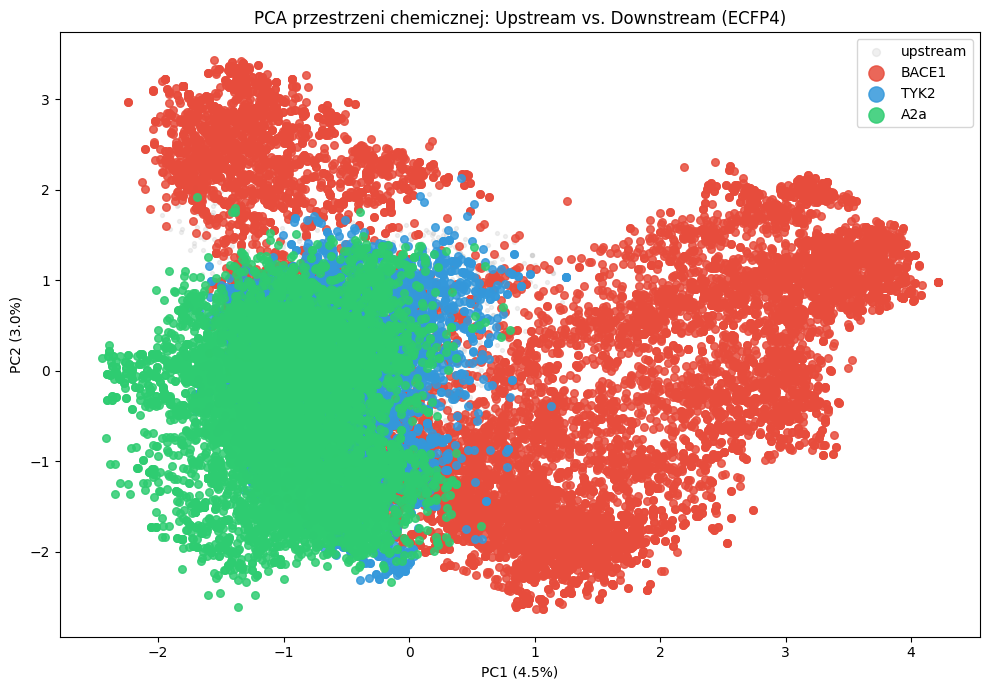

In [43]:
palette  = {"upstream": "#cccccc", "BACE1": "#e74c3c", "TYK2": "#3498db", "A2a": "#2ecc71"}
N_SAMPLE = 3000
rng      = np.random.default_rng(42)

idx_s   = rng.choice(len(fps_upstream), size=min(N_SAMPLE, len(fps_upstream)), replace=False)
all_fps = [fps_upstream[idx_s]]
labels  = ["upstream"] * len(idx_s)

for name, fps in fps_downstream.items():
    all_fps.append(fps)
    labels.extend([name] * len(fps))

X      = np.vstack(all_fps)
labels = np.array(labels)

# PCA
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
print(f"PCA wyjaśniona wariancja: PC1={pca.explained_variance_ratio_[0]:.2%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.2%}")

fig, ax = plt.subplots(figsize=(10, 7))
for lbl in ["upstream", "BACE1", "TYK2", "A2a"]:
    m = labels == lbl
    if not m.any(): continue
    ax.scatter(X_pca[m, 0], X_pca[m, 1],
               label=lbl, color=palette.get(lbl, "gray"),
               alpha=0.3 if lbl=="upstream" else 0.85,
               s=8   if lbl=="upstream" else 30,
               zorder=1 if lbl=="upstream" else 2)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title("PCA przestrzeni chemicznej: Upstream vs. Downstream (ECFP4)")
ax.legend(markerscale=2)
plt.tight_layout()
plt.savefig("./data/pca_chemical_space.png", dpi=150)
plt.show()

Obliczam UMAP (~2-5 min)...


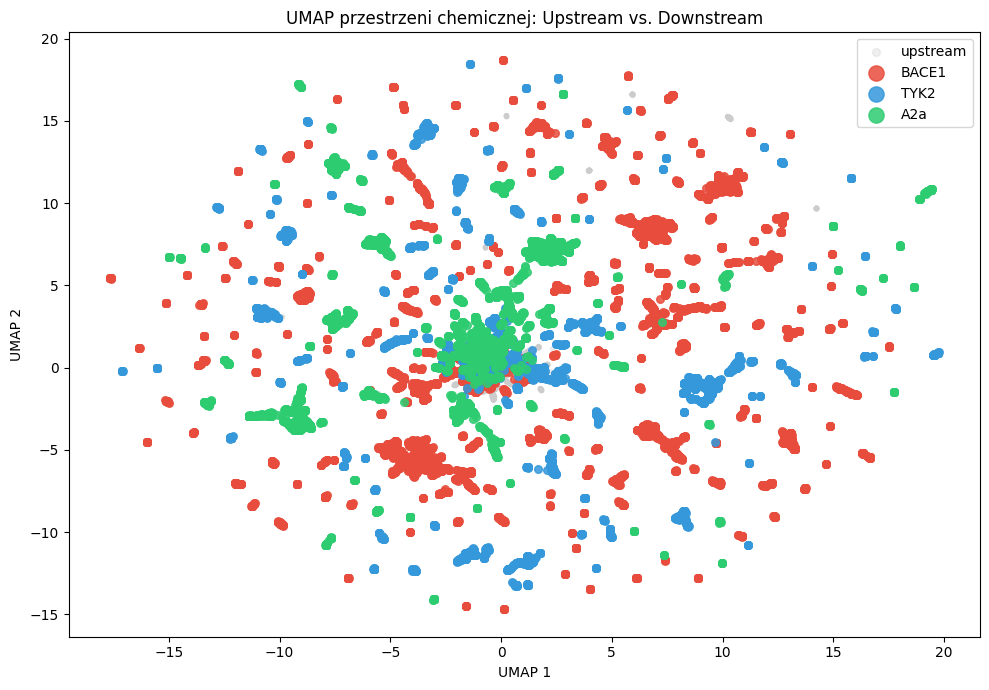

In [44]:
# UMAP (opcjonalny)
try:
    import umap
    print("Obliczam UMAP (~2-5 min)...")
    X_umap = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42).fit_transform(X)
    fig, ax = plt.subplots(figsize=(10, 7))
    for lbl in ["upstream", "BACE1", "TYK2", "A2a"]:
        m = labels == lbl
        if not m.any(): continue
        ax.scatter(X_umap[m, 0], X_umap[m, 1],
                   label=lbl, color=palette.get(lbl, "gray"),
                   alpha=0.3 if lbl=="upstream" else 0.85,
                   s=8   if lbl=="upstream" else 30,
                   zorder=1 if lbl=="upstream" else 2)
    ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
    ax.set_title("UMAP przestrzeni chemicznej: Upstream vs. Downstream")
    ax.legend(markerscale=2)
    plt.tight_layout()
    plt.savefig("./data/umap_chemical_space.png", dpi=150)
    plt.show()
except ImportError:
    print("umap-learn niedostępny")

## 8. Wykresy statystyczne


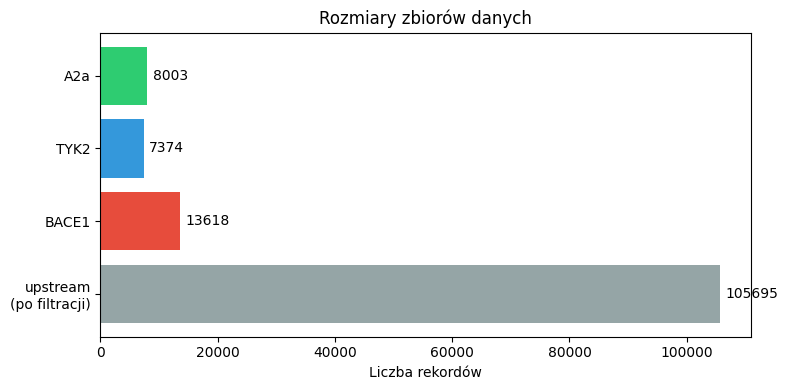

In [45]:
# Rozmiary zbiorów
counts = {"upstream\n(po filtracji)": len(df_upstream_filtered)}
counts.update({name: len(df) for name, df in downstream_clean.items()})

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(list(counts.keys()), list(counts.values()),
               color=["#95a5a6", "#e74c3c", "#3498db", "#2ecc71"])
ax.bar_label(bars, fmt="%d", padding=4)
ax.set_xlabel("Liczba rekordów")
ax.set_title("Rozmiary zbiorów danych")
plt.tight_layout()
plt.savefig("./data/dataset_sizes.png", dpi=150)
plt.show()

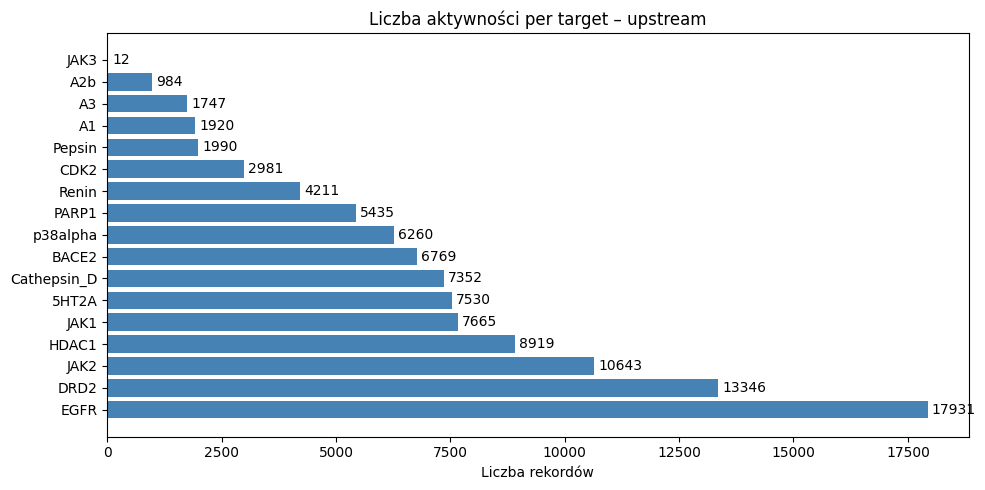

In [46]:
# Rozkład związków per target w upstream
target_counts = df_upstream_filtered["target_name"].value_counts()
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(target_counts.index, target_counts.values, color="steelblue")
ax.bar_label(bars, fmt="%d", padding=3)
ax.set_xlabel("Liczba rekordów")
ax.set_title("Liczba aktywności per target – upstream")
plt.tight_layout()
plt.savefig("./data/upstream_per_target.png", dpi=150)
plt.show()

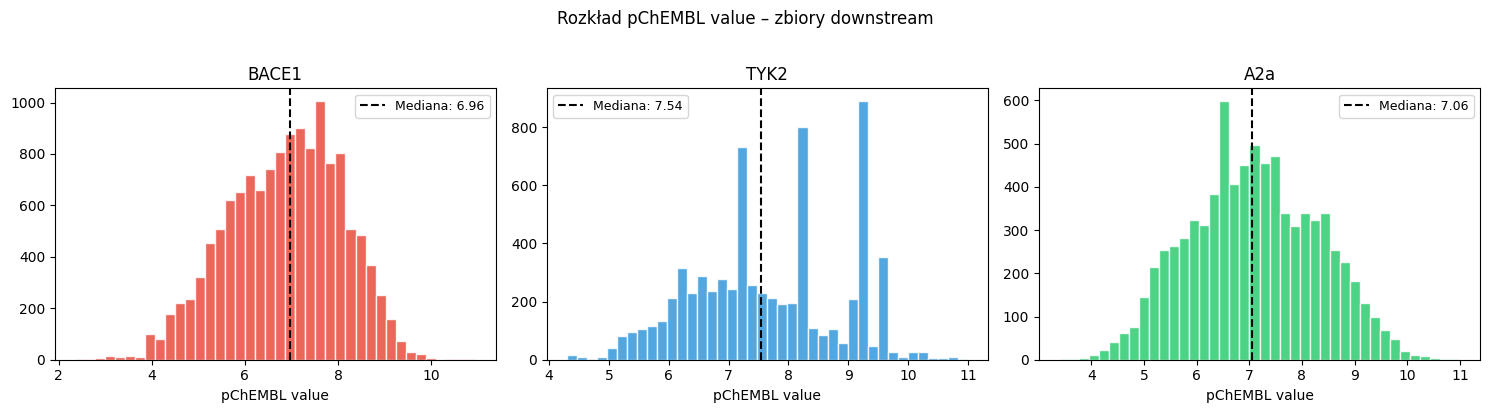

In [47]:
# Rozkład pChEMBL w downstream
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, df) in zip(axes, downstream_clean.items()):
    if "pchembl_value" in df.columns:
        vals = pd.to_numeric(df["pchembl_value"], errors="coerce").dropna()
        ax.hist(vals, bins=40, color=palette.get(name, "steelblue"),
                edgecolor="white", alpha=0.85)
        ax.axvline(vals.median(), color="black", linestyle="--",
                   label=f"Mediana: {vals.median():.2f}")
        ax.set_title(name)
        ax.set_xlabel("pChEMBL value")
        ax.legend(fontsize=9)
plt.suptitle("Rozkład pChEMBL value – zbiory downstream", y=1.02)
plt.tight_layout()
plt.savefig("./data/pchembl_distributions.png", dpi=150)
plt.show()

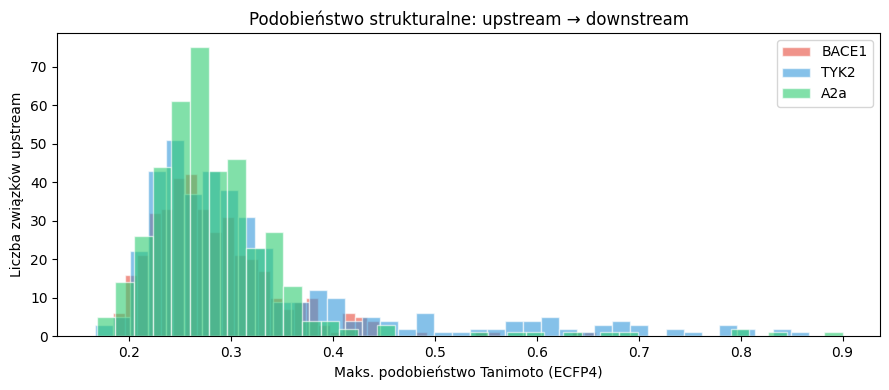

In [48]:
# Podobieństwo Tanimoto upstream → downstream
def np_to_bv(arr):
    bv = DataStructs.ExplicitBitVect(len(arr))
    for i, v in enumerate(arr):
        if v: bv.SetBit(i)
    return bv

fig, ax = plt.subplots(figsize=(9, 4))
for (name, fps_ds), color in zip(fps_downstream.items(),
                                   ["#e74c3c", "#3498db", "#2ecc71"]):
    if len(fps_ds) == 0: continue
    rng2  = np.random.default_rng(42)
    idx_q = rng2.choice(len(fps_upstream),
                         size=min(400, len(fps_upstream)), replace=False)
    ref_bvs = [np_to_bv(fps_ds[i]) for i in range(len(fps_ds))]
    sims = []
    for i in tqdm(idx_q, desc=f"Tanimoto→{name}", leave=False):
        q = np_to_bv(fps_upstream[i])
        sims.append(max(DataStructs.BulkTanimotoSimilarity(q, ref_bvs)))
    ax.hist(sims, bins=40, alpha=0.6, label=name, color=color, edgecolor="white")

ax.set_xlabel("Maks. podobieństwo Tanimoto (ECFP4)")
ax.set_ylabel("Liczba związków upstream")
ax.set_title("Podobieństwo strukturalne: upstream → downstream")
ax.legend()
plt.tight_layout()
plt.savefig("./data/tanimoto_similarity.png", dpi=150)
plt.show()

## 9. Binaryzacja etykiet aktywności


BACE1: aktywnych=10061  nieaktywnych=3380  (ratio=74.9%)
TYK2: aktywnych=6388  nieaktywnych=612  (ratio=91.3%)
A2a: aktywnych=6401  nieaktywnych=1575  (ratio=80.3%)


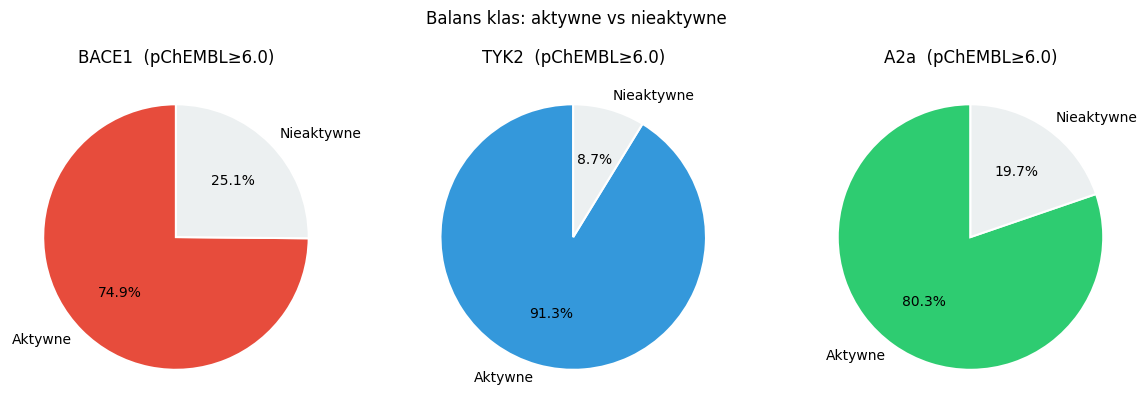

In [49]:
PCHEMBL_THRESHOLD = 6.0   # pIC50 ≥ 6 → aktywny (IC50 ≤ 1 µM)

downstream_labeled = {}
for name, df in downstream_clean.items():
    df = df.copy()
    if "pchembl_value" in df.columns:
        df["pchembl_value"] = pd.to_numeric(df["pchembl_value"], errors="coerce")
        df = df.dropna(subset=["pchembl_value"])
        df["active"] = (df["pchembl_value"] >= PCHEMBL_THRESHOLD).astype(int)
    else:
        df["standard_value"] = pd.to_numeric(df["standard_value"], errors="coerce")
        df = df.dropna(subset=["standard_value"])
        df["active"] = (df["standard_value"] <= 1000).astype(int)

    n_a = df["active"].sum()
    print(f"{name}: aktywnych={n_a}  nieaktywnych={len(df)-n_a}  "
          f"(ratio={n_a/len(df):.1%})")
    downstream_labeled[name] = df
    df.to_csv(f"./data/downstream/{name}_labeled.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (name, df) in zip(axes, downstream_labeled.items()):
    vals = df["active"].value_counts()
    ax.pie([vals.get(1,0), vals.get(0,0)],
           labels=["Aktywne", "Nieaktywne"],
           colors=[palette.get(name, "steelblue"), "#ecf0f1"],
           autopct="%1.1f%%", startangle=90,
           wedgeprops=dict(edgecolor="white", linewidth=1.5))
    ax.set_title(f"{name}  (pChEMBL≥{PCHEMBL_THRESHOLD})")
plt.suptitle("Balans klas: aktywne vs nieaktywne", y=1.02)
plt.tight_layout()
plt.savefig("./data/class_balance.png", dpi=150)
plt.show()

## 10. Podsumowanie


In [50]:
print("=" * 60)
print(" PODSUMOWANIE PREPROCESSINGU")
print("=" * 60)

print(f"\nUPSTREAM (ChEMBL API – {len(UPSTREAM_TARGETS)} targetów)")
print(f"  Surowy (pobrany):            {len(df_upstream_raw):>8}")
print(f"  Po czyszczeniu:              {len(df_upstream):>8}")
print(f"  Po usunięciu DS leakage:     {len(df_upstream_filtered):>8}")
print(f"  Usuniętych (leakage+clean):  {n_removed:>8}  "
      f"({100*n_removed/len(df_upstream):.1f}%)")

print(f"\nDOWNSTREAM:")
for name, df in downstream_labeled.items():
    n_a = df["active"].sum() if "active" in df.columns else "?"
    print(f"  {name:<8}: {len(df):>6} rekordów  |  aktywnych: {n_a}")

print("\nPliki wyjściowe:")
print("  ./data/upstream/upstream_filtered.csv")
print("  ./data/upstream/fps_upstream.npy")
for name in DOWNSTREAM_TARGETS:
    print(f"  ./data/downstream/{name}_labeled.csv")
    print(f"  ./data/downstream/fps_{name}.npy")
print("\n✅ Preprocessing zakończony!")

 PODSUMOWANIE PREPROCESSINGU

UPSTREAM (ChEMBL API – 18 targetów)
  Surowy (pobrany):              137851
  Po czyszczeniu:                119816
  Po usunięciu DS leakage:       105695
  Usuniętych (leakage+clean):     14121  (11.8%)

DOWNSTREAM:
  BACE1   :  13441 rekordów  |  aktywnych: 10061
  TYK2    :   7000 rekordów  |  aktywnych: 6388
  A2a     :   7976 rekordów  |  aktywnych: 6401

Pliki wyjściowe:
  ./data/upstream/upstream_filtered.csv
  ./data/upstream/fps_upstream.npy
  ./data/downstream/BACE1_labeled.csv
  ./data/downstream/fps_BACE1.npy
  ./data/downstream/TYK2_labeled.csv
  ./data/downstream/fps_TYK2.npy
  ./data/downstream/A2a_labeled.csv
  ./data/downstream/fps_A2a.npy

✅ Preprocessing zakończony!
